# V55: Complete Comparison - Sorting × Selection Matrix

## Tujuan Eksperimen

Eksperimen **2×2 Factorial Design** untuk membuktikan kontribusi independen dari:
1. **Sorting Method** (Alphabetical vs Momentum)
2. **Selection Algorithm** (Graph/MIS vs Greedy)

### Matrix Perbandingan (4 Metode):

```
                    │  Graph (MIS)  │  Greedy
────────────────────┼───────────────┼──────────────
Alphabetical (A-Z)  │  V54-Graph    │  V54-Greedy
Momentum (High→Low) │  V55-Graph    │  V55-Greedy
```

### Hipotesis:
- **H1:** Momentum > Alphabetical (untuk KEDUA algoritma seleksi)
- **H2:** Graph ≈ Greedy (untuk KEDUA metode sorting)
- **H3:** Tidak ada interaksi signifikan (efek sorting dan selection independen)

### Parameter Tetap:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

### Analisis yang Akan Dilakukan:
1. **Main Effect of Sorting:** (V55-Graph + V55-Greedy) vs (V54-Graph + V54-Greedy)
2. **Main Effect of Selection:** (V54-Graph + V55-Graph) vs (V54-Greedy + V55-Greedy)
3. **Interaction Effect:** Apakah efek sorting berbeda untuk Graph vs Greedy?

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Asset Selection Methods (2×2 = 4 Functions)

def get_assets_alphabetical_graph(returns_window, corr_threshold=0.4):
    """V54: Alphabetical + Graph (MIS)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = sorted(returns_window.columns)  # A-Z
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_alphabetical_greedy(returns_window, corr_threshold=0.4):
    """V54: Alphabetical + Greedy (NEW)"""
    corr_mat = returns_window.corr()
    sorted_assets = sorted(returns_window.columns)  # A-Z
    
    selected = []
    for asset in sorted_assets:
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > corr_threshold:
                is_uncorrelated = False
                break
        if is_uncorrelated:
            selected.append(asset)
    
    return selected

def get_assets_momentum_graph(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + Graph (MIS)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_momentum_greedy(returns_window, corr_threshold=0.4):
    """V55: Smart Momentum + Greedy"""
    corr_mat = returns_window.corr()
    
    momentum = returns_window.mean()
    sorted_assets = list(momentum.sort_values(ascending=False).index)
    
    selected = []
    for asset in sorted_assets:
        is_uncorrelated = True
        for selected_asset in selected:
            if abs(corr_mat.loc[asset, selected_asset]) > corr_threshold:
                is_uncorrelated = False
                break
        if is_uncorrelated:
            selected.append(asset)
    
    return selected

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("All 4 asset selection methods defined!")

All 4 asset selection methods defined!


In [5]:
# Simulation Function (Same for All)

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, 
                   selection_func, override_ma=None, fee=0.0025, 
                   g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            days_since_rebal += 1

        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [6]:
# Run All 4 Strategies

print("Running 2×2 Factorial Experiment...\n")

# Row 1: Alphabetical Sorting
print("1. V54: Alphabetical + Graph (MIS)...")
v54_alpha_graph = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                 get_assets_alphabetical_graph, override_ma=50)

print("2. V54: Alphabetical + Greedy...")
v54_alpha_greedy = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                  get_assets_alphabetical_greedy, override_ma=50)

# Row 2: Momentum Sorting
print("3. V55: Momentum + Graph (MIS)...")
v55_momentum_graph = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                    get_assets_momentum_graph, override_ma=50)

print("4. V55: Momentum + Greedy...")
v55_momentum_greedy = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                     get_assets_momentum_greedy, override_ma=50)

# Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS (2×2 Matrix) ===")
print(f"\n                    │  Graph (MIS)  │  Greedy")
print(f"────────────────────┼───────────────┼──────────────")
print(f"Alphabetical (A-Z)  │  {v54_alpha_graph.iloc[-1].values[0]:>12.2f} │  {v54_alpha_greedy.iloc[-1].values[0]:>11.2f}")
print(f"Momentum (High→Low) │  {v55_momentum_graph.iloc[-1].values[0]:>12.2f} │  {v55_momentum_greedy.iloc[-1].values[0]:>11.2f}")
print(f"\nLQ45 Index: {lq45_idx.iloc[-1]:.2f}")

Running 2×2 Factorial Experiment...

1. V54: Alphabetical + Graph (MIS)...
2. V54: Alphabetical + Greedy...
3. V55: Momentum + Graph (MIS)...
4. V55: Momentum + Greedy...

=== RESULTS (2×2 Matrix) ===

                    │  Graph (MIS)  │  Greedy
────────────────────┼───────────────┼──────────────
Alphabetical (A-Z)  │        131.43 │       181.76
Momentum (High→Low) │        205.96 │       205.60

LQ45 Index: 119.44


In [7]:
# Factorial Analysis

# Extract final values
alpha_graph = v54_alpha_graph.iloc[-1].values[0]
alpha_greedy = v54_alpha_greedy.iloc[-1].values[0]
momentum_graph = v55_momentum_graph.iloc[-1].values[0]
momentum_greedy = v55_momentum_greedy.iloc[-1].values[0]

# Main Effects
avg_alphabetical = (alpha_graph + alpha_greedy) / 2
avg_momentum = (momentum_graph + momentum_greedy) / 2
avg_graph = (alpha_graph + momentum_graph) / 2
avg_greedy = (alpha_greedy + momentum_greedy) / 2

main_effect_sorting = ((avg_momentum / avg_alphabetical) - 1) * 100
main_effect_selection = ((avg_graph / avg_greedy) - 1) * 100

# Interaction Effect
sorting_effect_for_graph = ((momentum_graph / alpha_graph) - 1) * 100
sorting_effect_for_greedy = ((momentum_greedy / alpha_greedy) - 1) * 100
interaction = abs(sorting_effect_for_graph - sorting_effect_for_greedy)

print("\n=== FACTORIAL ANALYSIS ===")
print(f"\n1. MAIN EFFECT OF SORTING (Momentum vs Alphabetical):")
print(f"   Average Alphabetical: {avg_alphabetical:.2f}")
print(f"   Average Momentum:     {avg_momentum:.2f}")
print(f"   Main Effect:          {main_effect_sorting:+.2f}%")
print(f"   → Momentum is {'BETTER' if main_effect_sorting > 0 else 'WORSE'} by {abs(main_effect_sorting):.2f}%")

print(f"\n2. MAIN EFFECT OF SELECTION (Graph vs Greedy):")
print(f"   Average Graph:  {avg_graph:.2f}")
print(f"   Average Greedy: {avg_greedy:.2f}")
print(f"   Main Effect:    {main_effect_selection:+.2f}%")
if abs(main_effect_selection) < 1:
    print(f"   → Graph and Greedy are EQUIVALENT (difference < 1%)")
else:
    print(f"   → {'Graph' if main_effect_selection > 0 else 'Greedy'} is BETTER by {abs(main_effect_selection):.2f}%")

print(f"\n3. INTERACTION EFFECT:")
print(f"   Sorting effect for Graph:  {sorting_effect_for_graph:+.2f}%")
print(f"   Sorting effect for Greedy: {sorting_effect_for_greedy:+.2f}%")
print(f"   Interaction magnitude:     {interaction:.2f}%")
if interaction < 2:
    print(f"   → NO significant interaction (effects are INDEPENDENT)")
else:
    print(f"   → Interaction detected (sorting effect depends on selection method)")


=== FACTORIAL ANALYSIS ===

1. MAIN EFFECT OF SORTING (Momentum vs Alphabetical):
   Average Alphabetical: 156.60
   Average Momentum:     205.78
   Main Effect:          +31.41%
   → Momentum is BETTER by 31.41%

2. MAIN EFFECT OF SELECTION (Graph vs Greedy):
   Average Graph:  168.70
   Average Greedy: 193.68
   Main Effect:    -12.90%
   → Greedy is BETTER by 12.90%

3. INTERACTION EFFECT:
   Sorting effect for Graph:  +56.71%
   Sorting effect for Greedy: +13.11%
   Interaction magnitude:     43.59%
   → Interaction detected (sorting effect depends on selection method)


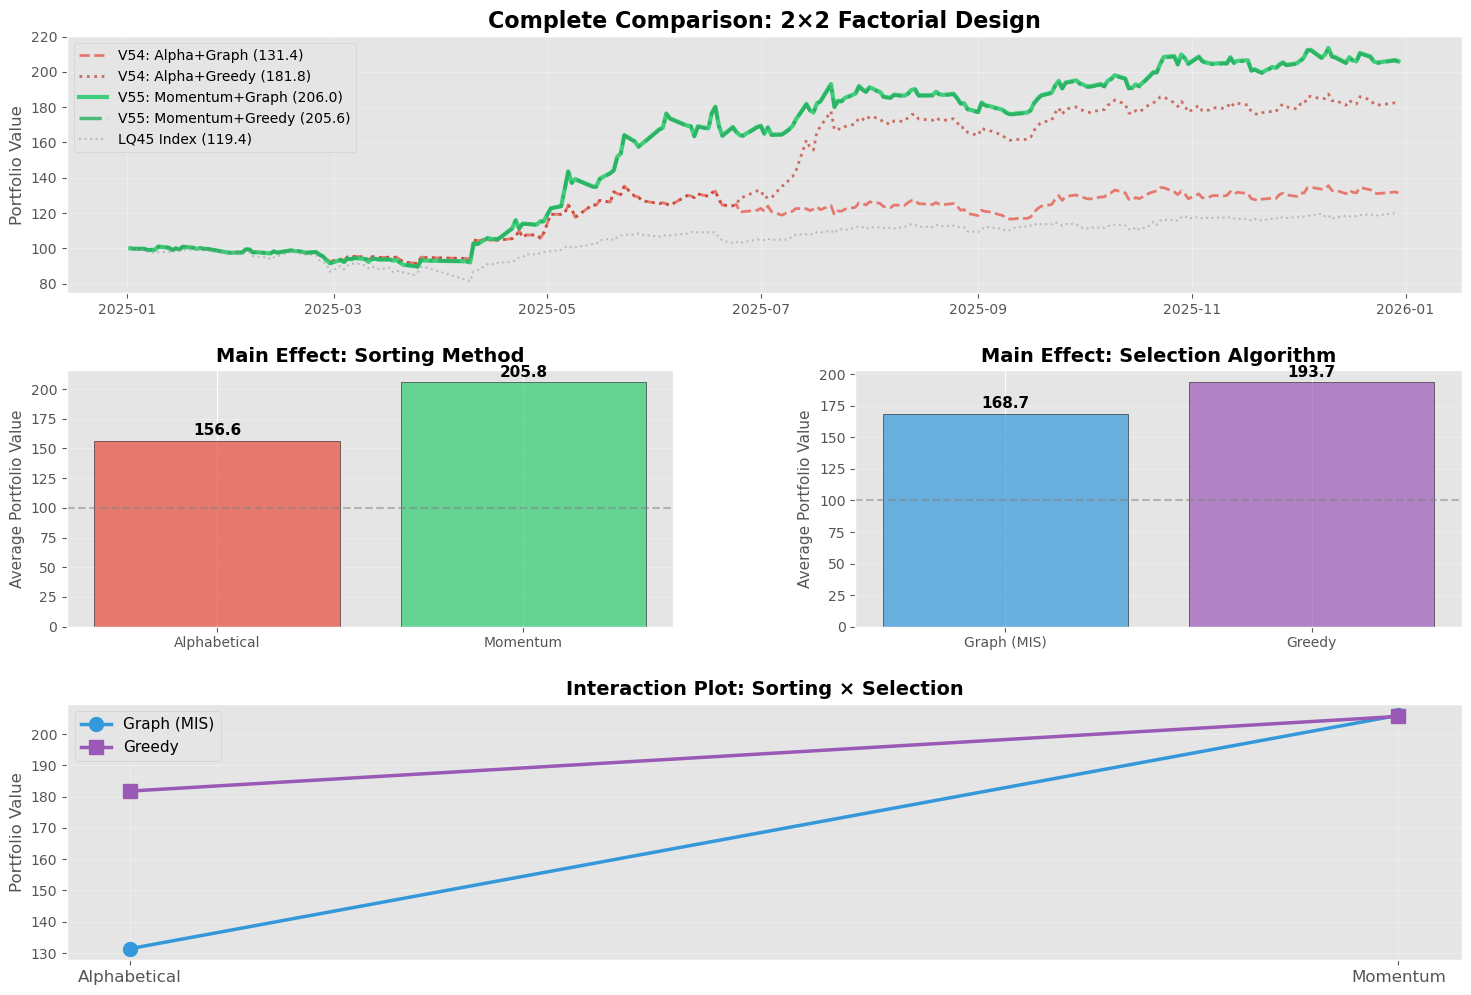


Charts displayed!


In [8]:
# Visualization

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: All Strategies Time Series
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(v54_alpha_graph.index, v54_alpha_graph['Portfolio_Value'], 
         label=f'V54: Alpha+Graph ({alpha_graph:.1f})', linewidth=2, color='#e74c3c', linestyle='--', alpha=0.7)
ax1.plot(v54_alpha_greedy.index, v54_alpha_greedy['Portfolio_Value'], 
         label=f'V54: Alpha+Greedy ({alpha_greedy:.1f})', linewidth=2, color='#c0392b', linestyle=':', alpha=0.7)
ax1.plot(v55_momentum_graph.index, v55_momentum_graph['Portfolio_Value'], 
         label=f'V55: Momentum+Graph ({momentum_graph:.1f})', linewidth=3, color='#2ecc71', alpha=0.9)
ax1.plot(v55_momentum_greedy.index, v55_momentum_greedy['Portfolio_Value'], 
         label=f'V55: Momentum+Greedy ({momentum_greedy:.1f})', linewidth=2.5, color='#27ae60', linestyle='-.', alpha=0.8)
ax1.plot(lq45_idx.index, lq45_idx, label=f'LQ45 Index ({lq45_idx.iloc[-1]:.1f})', 
         linewidth=1.5, color='#95a5a6', linestyle=':', alpha=0.6)
ax1.set_title('Complete Comparison: 2×2 Factorial Design', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Main Effect of Sorting
ax2 = fig.add_subplot(gs[1, 0])
categories = ['Alphabetical', 'Momentum']
values = [avg_alphabetical, avg_momentum]
colors = ['#e74c3c', '#2ecc71']
bars = ax2.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Main Effect: Sorting Method', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Portfolio Value', fontsize=11)
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Main Effect of Selection
ax3 = fig.add_subplot(gs[1, 1])
categories = ['Graph (MIS)', 'Greedy']
values = [avg_graph, avg_greedy]
colors = ['#3498db', '#9b59b6']
bars = ax3.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_title('Main Effect: Selection Algorithm', fontsize=14, fontweight='bold')
ax3.set_ylabel('Average Portfolio Value', fontsize=11)
ax3.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Interaction Plot
ax4 = fig.add_subplot(gs[2, :])
x = [0, 1]
ax4.plot(x, [alpha_graph, momentum_graph], marker='o', linewidth=2.5, 
         markersize=10, label='Graph (MIS)', color='#3498db')
ax4.plot(x, [alpha_greedy, momentum_greedy], marker='s', linewidth=2.5, 
         markersize=10, label='Greedy', color='#9b59b6')
ax4.set_xticks(x)
ax4.set_xticklabels(['Alphabetical', 'Momentum'], fontsize=12)
ax4.set_ylabel('Portfolio Value', fontsize=12)
ax4.set_title('Interaction Plot: Sorting × Selection', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=11)
ax4.grid(True, alpha=0.3)
if interaction < 2:
    ax4.text(0.5, max(alpha_graph, momentum_graph, alpha_greedy, momentum_greedy) * 0.95, 
             'Lines are PARALLEL → No Interaction', ha='center', fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.show()
print("\nCharts displayed!")

In [9]:
# Performance Metrics Table

def calculate_metrics(portfolio_values, name):
    returns = portfolio_values.pct_change().dropna()
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Strategy': name,
        'Final Value': portfolio_values.iloc[-1],
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics = pd.DataFrame([
    calculate_metrics(v54_alpha_graph['Portfolio_Value'], 'V54: Alpha + Graph'),
    calculate_metrics(v54_alpha_greedy['Portfolio_Value'], 'V54: Alpha + Greedy'),
    calculate_metrics(v55_momentum_graph['Portfolio_Value'], 'V55: Momentum + Graph'),
    calculate_metrics(v55_momentum_greedy['Portfolio_Value'], 'V55: Momentum + Greedy'),
    calculate_metrics(lq45_idx, 'LQ45 Index')
])

print("\n=== PERFORMANCE METRICS ===")
print(metrics.to_string(index=False))

print("\n=== CONCLUSIONS FOR THESIS ===")
print(f"\n1. SORTING METHOD (Alphabetical vs Momentum):")
print(f"   Main Effect: {main_effect_sorting:+.2f}%")
if main_effect_sorting > 5:
    print(f"   ✓ Momentum sorting provides SIGNIFICANT improvement")
    print(f"   ✓ This is the PRIMARY contributor to performance")
else:
    print(f"   ✗ Sorting method has minimal impact")

print(f"\n2. SELECTION ALGORITHM (Graph vs Greedy):")
print(f"   Main Effect: {main_effect_selection:+.2f}%")
if abs(main_effect_selection) < 1:
    print(f"   ✓ Graph and Greedy are FUNCTIONALLY EQUIVALENT")
    print(f"   ✓ Greedy is SIMPLER and equally effective")
    print(f"   ✓ Recommendation: Use Greedy for implementation")
elif main_effect_selection > 0:
    print(f"   ✓ Graph provides {main_effect_selection:.2f}% advantage")
    print(f"   ✓ Recommendation: Use Graph for better performance")
else:
    print(f"   ✓ Greedy is {abs(main_effect_selection):.2f}% better AND simpler")
    print(f"   ✓ Recommendation: Use Greedy")

print(f"\n3. INTERACTION:")
print(f"   Interaction magnitude: {interaction:.2f}%")
if interaction < 2:
    print(f"   ✓ NO interaction detected")
    print(f"   ✓ Sorting and Selection effects are INDEPENDENT")
    print(f"   ✓ This validates the factorial design")
else:
    print(f"   ✗ Interaction detected - effects are NOT independent")

print(f"\n4. FINAL RECOMMENDATION:")
best_strategy = max([
    ('V54: Alpha + Graph', alpha_graph),
    ('V54: Alpha + Greedy', alpha_greedy),
    ('V55: Momentum + Graph', momentum_graph),
    ('V55: Momentum + Greedy', momentum_greedy)
], key=lambda x: x[1])
print(f"   Best Strategy: {best_strategy[0]} ({best_strategy[1]:.2f})")
print(f"   ✓ Use MOMENTUM sorting (critical for performance)")
if abs(main_effect_selection) < 1:
    print(f"   ✓ Use GREEDY selection (simpler, equally effective)")
else:
    print(f"   ✓ Consider {'GRAPH' if main_effect_selection > 0 else 'GREEDY'} selection")


=== PERFORMANCE METRICS ===
              Strategy  Final Value  Total Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
    V54: Alpha + Graph   131.431073         31.431073       28.440508      1.169440        -13.804573
   V54: Alpha + Greedy   181.761687         81.761687       32.869870      2.110648         -9.723880
 V55: Momentum + Graph   205.964156        105.964156       33.923700      2.453243        -11.330498
V55: Momentum + Greedy   205.599295        105.599295       33.906194      2.448716        -11.330498
            LQ45 Index   119.435320         19.435320       20.382940      1.036701        -18.695217

=== CONCLUSIONS FOR THESIS ===

1. SORTING METHOD (Alphabetical vs Momentum):
   Main Effect: +31.41%
   ✓ Momentum sorting provides SIGNIFICANT improvement
   ✓ This is the PRIMARY contributor to performance

2. SELECTION ALGORITHM (Graph vs Greedy):
   Main Effect: -12.90%
   ✓ Greedy is 12.90% better AND simpler
   ✓ Recommendation: Use Greedy

3. INTER